In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, brier_score_loss
)
import lightgbm as lgb

RANDOM_STATE = 5243

sns.set_theme(style="whitegrid")

## Load Data

In [40]:

DATA_DIR = Path("../data")


train = pd.read_csv(DATA_DIR / "train_ohe_with_y2.csv")
test  = pd.read_csv(DATA_DIR / "test_ohe_with_y2.csv")

X_train = train.drop(columns=["target_y"])
y_train = train["target_y"].astype(int)
X_test  = test.drop(columns=["target_y"])
y_test  = test["target_y"].astype(int)


In [41]:
print(f"Train shape: {X_train.shape}, denial rate: {(1 - y_train.mean()):.3f}")
print(f"Test shape:  {X_test.shape}, denial rate: {(1 - y_test.mean()):.3f}")


Train shape: (111992, 97), denial rate: 0.204
Test shape:  (27999, 97), denial rate: 0.204


In [42]:
feature_columns = X_train.columns.tolist()
with open("feature_columns.json", "w") as f:
    json.dump(feature_columns, f, indent=2)


dupes = X_train.columns[X_train.columns.duplicated()].tolist()
assert len(dupes) == 0, f"Duplicate columns found: {dupes}"
print(f"Saved feature_columns.json with {len(feature_columns)} features.")

Saved feature_columns.json with 97 features.


In [43]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_metrics(model, X, y, cv):
    """Run 5-fold CV and return mean ± std for AUC and PR-AUC."""
    auc_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    pr_scores  = cross_val_score(model, X, y, cv=cv, scoring="average_precision", n_jobs=-1)
    return {
        "roc_auc_mean": auc_scores.mean(), "roc_auc_std": auc_scores.std(),
        "pr_auc_mean":  pr_scores.mean(),  "pr_auc_std":  pr_scores.std(),
    }

In [44]:


print("\n--- Logistic Regression ---")

logit = LogisticRegression(
    solver="saga",         # supports both L1 and L2
    max_iter=10000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

logit_grid = {
    "penalty": ["l1", "l2"],
    "C":       [0.01, 0.1, 1, 10],
}

logit_search = GridSearchCV(
    logit, logit_grid,
    cv=cv,
    scoring="average_precision",   # tune for PR-AUC
    n_jobs=-1,
    verbose=1,
    refit=True,
)
logit_search.fit(X_train, y_train)

print("Best params:", logit_search.best_params_)
print("Best CV PR-AUC:", logit_search.best_score_)

best_logit = logit_search.best_estimator_
logit_cv = cv_metrics(best_logit, X_train, y_train, cv)
print(f"Logistic CV — ROC-AUC: {logit_cv['roc_auc_mean']:.4f} ± {logit_cv['roc_auc_std']:.4f}")
print(f"            PR-AUC:  {logit_cv['pr_auc_mean']:.4f} ± {logit_cv['pr_auc_std']:.4f}")



--- Logistic Regression ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value a

Best params: {'C': 0.01, 'penalty': 'l2'}
Best CV PR-AUC: 0.8627584005040918


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value a

Logistic CV — ROC-AUC: 0.6911 ± 0.0039
            PR-AUC:  0.8628 ± 0.0021


In [45]:

# Model 2 — Random Forest

print("\n--- Random Forest ---")

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_dist = {
    "n_estimators":     [300, 500],
    "max_depth":        [None, 10, 20],
    "min_samples_leaf": [1, 5, 20],
    "max_features":     ["sqrt", 0.3],
}

rf_search = RandomizedSearchCV(
    rf, rf_dist,
    n_iter=20,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True,
)
rf_search.fit(X_train, y_train)

print("Best params:", rf_search.best_params_)
print("Best CV PR-AUC:", rf_search.best_score_)

best_rf = rf_search.best_estimator_
rf_cv = cv_metrics(best_rf, X_train, y_train, cv)
print(f"RF CV — ROC-AUC: {rf_cv['roc_auc_mean']:.4f} ± {rf_cv['roc_auc_std']:.4f}")
print(f"      PR-AUC:  {rf_cv['pr_auc_mean']:.4f} ± {rf_cv['pr_auc_std']:.4f}")




--- Random Forest ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'n_estimators': 300, 'min_samples_leaf': 5, 'max_features': 0.3, 'max_depth': 20}
Best CV PR-AUC: 0.9553956928127466
RF CV — ROC-AUC: 0.8854 ± 0.0008
      PR-AUC:  0.9554 ± 0.0009


In [46]:

# Model 3 — LightGBM

print("\n--- LightGBM ---")

# scale_pos_weight handles class imbalance natively
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

lgbm = lgb.LGBMClassifier(
    objective="binary",
    scale_pos_weight=neg_pos_ratio,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

lgbm_dist = {
    "num_leaves":        [31, 63, 127],
    "learning_rate":     [0.03, 0.05, 0.1],
    "n_estimators":      [500, 1000],
    "min_child_samples": [20, 100],
    "subsample":         [0.8, 1.0],
    "colsample_bytree":  [0.8, 1.0],
}

lgbm_search = RandomizedSearchCV(
    lgbm, lgbm_dist,
    n_iter=30,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True,
)
lgbm_search.fit(X_train, y_train)

print("Best params:", lgbm_search.best_params_)
print("Best CV PR-AUC:", lgbm_search.best_score_)

best_lgbm = lgbm_search.best_estimator_
lgbm_cv = cv_metrics(best_lgbm, X_train, y_train, cv)
print(f"LightGBM CV — ROC-AUC: {lgbm_cv['roc_auc_mean']:.4f} ± {lgbm_cv['roc_auc_std']:.4f}")
print(f"            PR-AUC:  {lgbm_cv['pr_auc_mean']:.4f} ± {lgbm_cv['pr_auc_std']:.4f}")




--- LightGBM ---
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 500, 'min_child_samples': 20, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
Best CV PR-AUC: 0.9564859470038224
LightGBM CV — ROC-AUC: 0.8874 ± 0.0006
            PR-AUC:  0.9565 ± 0.0007


In [47]:

cv_summary = pd.DataFrame({
    "Logistic":  logit_cv,
    "RandomForest": rf_cv,
    "LightGBM":  lgbm_cv,
}).T
cv_summary.to_csv("cv_summary.csv")
print("\n=== CV Summary ===")
print(cv_summary.round(4))


=== CV Summary ===
              roc_auc_mean  roc_auc_std  pr_auc_mean  pr_auc_std
Logistic            0.6911       0.0039       0.8628      0.0021
RandomForest        0.8854       0.0008       0.9554      0.0009
LightGBM            0.8874       0.0006       0.9565      0.0007


In [48]:
from sklearn.ensemble import RandomForestClassifier

best_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    max_features=0.3,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
best_rf.fit(X_train, y_train)   # X_train is now sanitized
print("RF refit complete on sanitized columns")

RF refit complete on sanitized columns


In [49]:
print("LGBM expects:", best_lgbm.feature_name_[:5])
print("X_test has:  ", X_test.columns.tolist()[:5])

LGBM expects: ['loan_amount', 'loan_to_value_ratio', 'loan_term', 'property_value', 'income']
X_test has:   ['loan_amount', 'loan_to_value_ratio', 'loan_term', 'property_value', 'income']


In [50]:

# 7. Test-set evaluation — all three models

def evaluate_on_test(model, X_test, y_test, name):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    return {
        "model":     name,
        "accuracy":  accuracy_score(y_test, y_pred),
        "roc_auc":   roc_auc_score(y_test, y_proba),
        "pr_auc":    average_precision_score(y_test, y_proba),
        "precision_denial": precision_score(y_test, y_pred, pos_label=0),
        "recall_denial":    recall_score(y_test, y_pred, pos_label=0),
        "f1_denial":        f1_score(y_test, y_pred, pos_label=0),
        "brier":     brier_score_loss(y_test, y_proba),
    }

test_results = pd.DataFrame([
    evaluate_on_test(best_logit, X_test, y_test, "Logistic"),
    evaluate_on_test(best_rf,    X_test, y_test, "RandomForest"),
    evaluate_on_test(best_lgbm,  X_test, y_test, "LightGBM"),
]).set_index("model")

print("\n=== Test-set Performance ===")
print(test_results.round(4))
test_results.to_csv("test_metrics.csv")




=== Test-set Performance ===
              accuracy  roc_auc  pr_auc  precision_denial  recall_denial  \
model                                                                      
Logistic        0.6543   0.6891  0.8617            0.3170         0.6035   
RandomForest    0.8855   0.8879  0.9561            0.7312         0.6924   
LightGBM        0.8647   0.8900  0.9576            0.6457         0.7440   

              f1_denial   brier  
model                            
Logistic         0.4157  0.2175  
RandomForest     0.7113  0.0931  
LightGBM         0.6914  0.1070  


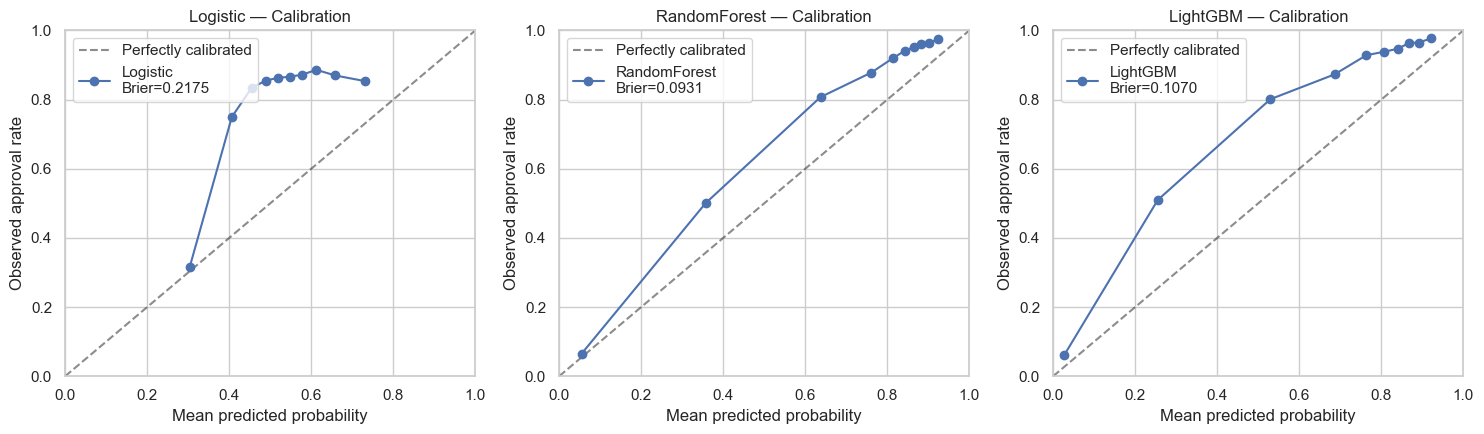

In [51]:

# 8. Calibration curves — all three models on one plot

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, model) in zip(axes, [
    ("Logistic", best_logit),
    ("RandomForest", best_rf),
    ("LightGBM", best_lgbm),
]):
    y_proba = model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy="quantile")
    
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfectly calibrated")
    ax.plot(mean_pred, frac_pos, "o-", label=f"{name}\nBrier={brier_score_loss(y_test, y_proba):.4f}")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed approval rate")
    ax.set_title(f"{name} — Calibration")
    ax.legend(loc="upper left")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("calibration_curves.png", dpi=120, bbox_inches="tight")
plt.show()



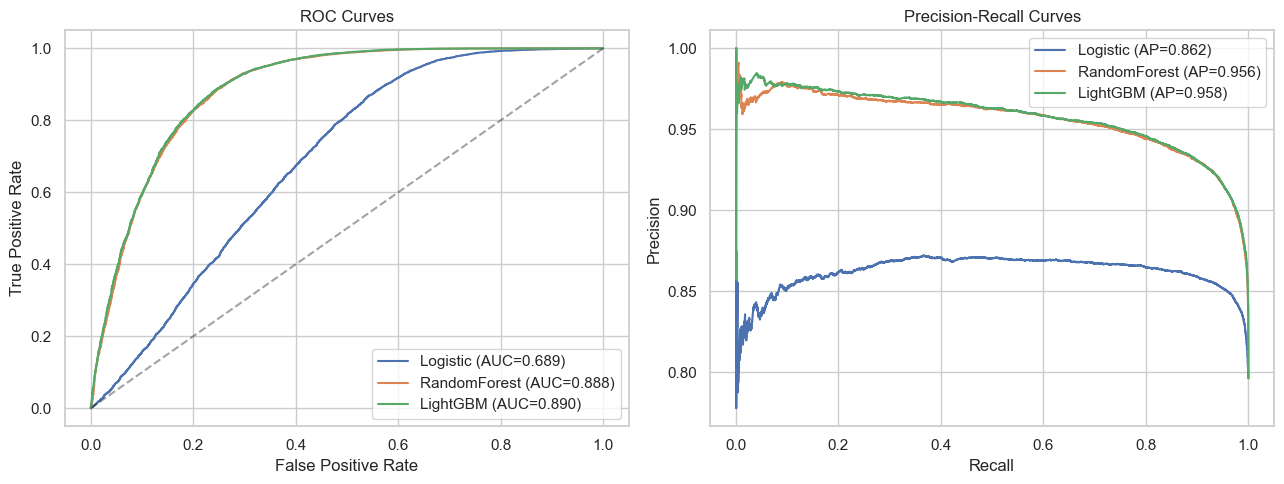

In [52]:

# 9. ROC and PR curves — all three on one plot each

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, model in [("Logistic", best_logit), ("RandomForest", best_rf), ("LightGBM", best_lgbm)]:
    y_proba = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend()

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves")
axes[1].legend()

plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=120, bbox_inches="tight")
plt.show()

=== LightGBM Calibrated ===
ROC-AUC:  0.8910
PR-AUC:   0.9582
Brier:    0.0815
F1 (denial): 0.7007


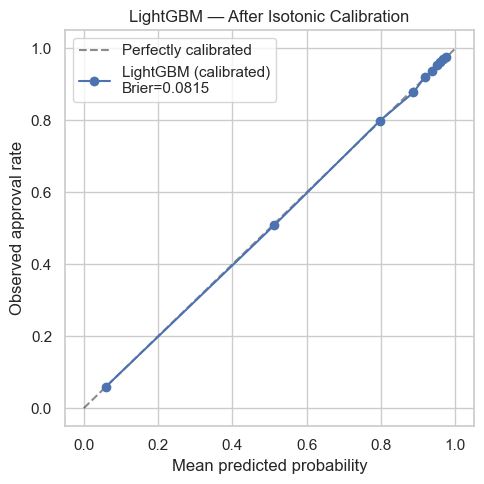

In [53]:

# 10. Calibrate LightGBM candidate with isotonic regression

from sklearn.calibration import CalibratedClassifierCV


lgbm_calibrated = CalibratedClassifierCV(
    estimator=lgb.LGBMClassifier(
        objective="binary",
        scale_pos_weight=neg_pos_ratio,
        num_leaves=63,
        n_estimators=500,
        learning_rate=0.03,
        min_child_samples=20,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ),
    method="isotonic",
    cv=5,
)
lgbm_calibrated.fit(X_train, y_train)

# Evaluate on test
y_proba_cal = lgbm_calibrated.predict_proba(X_test)[:, 1]
y_pred_cal  = lgbm_calibrated.predict(X_test)

print("=== LightGBM Calibrated ===")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_cal):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, y_proba_cal):.4f}")
print(f"Brier:    {brier_score_loss(y_test, y_proba_cal):.4f}")
print(f"F1 (denial): {f1_score(y_test, y_pred_cal, pos_label=0):.4f}")

# Calibration curve
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
frac_pos, mean_pred = calibration_curve(y_test, y_proba_cal, n_bins=10, strategy="quantile")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfectly calibrated")
ax.plot(mean_pred, frac_pos, "o-", label=f"LightGBM (calibrated)\nBrier={brier_score_loss(y_test, y_proba_cal):.4f}")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed approval rate")
ax.set_title("LightGBM — After Isotonic Calibration")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("calibration_lgbm_after.png", dpi=120, bbox_inches="tight")
plt.show()


candidate_model = lgbm_calibrated


# shape

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (27999, 97)


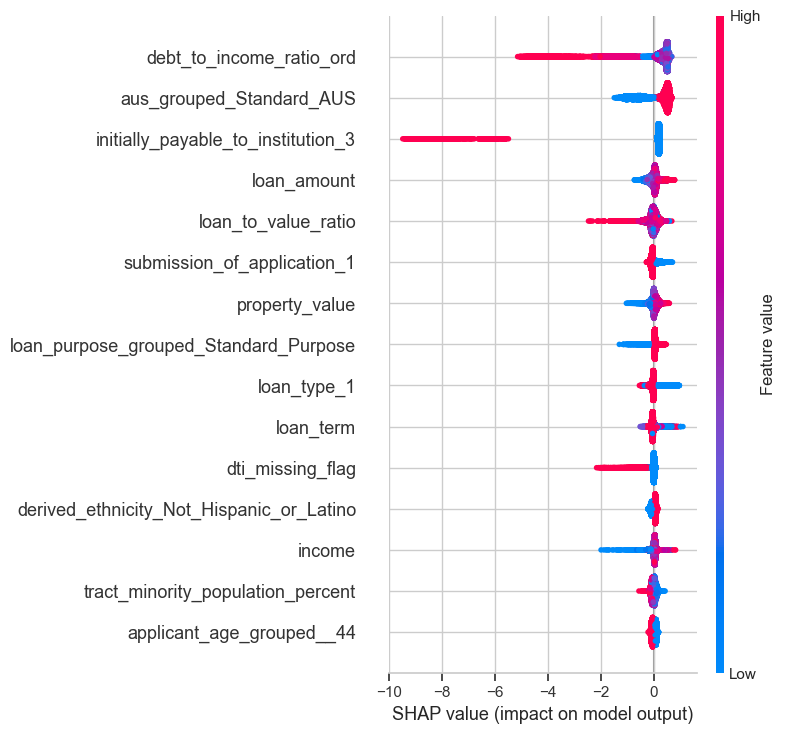

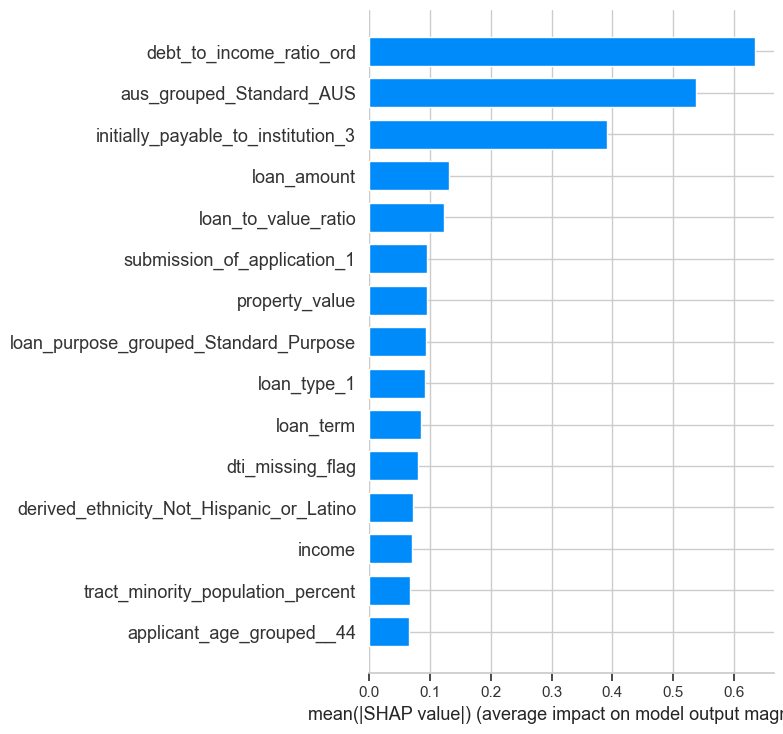

In [54]:
import shap


final_lgbm_raw = lgb.LGBMClassifier(
    objective="binary",
    scale_pos_weight=neg_pos_ratio,
    num_leaves=63,
    n_estimators=500,
    learning_rate=0.03,
    min_child_samples=20,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)
final_lgbm_raw.fit(X_train, y_train)

# TreeSHAP — fast and exact
explainer = shap.TreeExplainer(final_lgbm_raw)
shap_values = explainer.shap_values(X_test)

# Save for the app (huge time-saver later)
np.save("shap_values_test.npy", shap_values)
print(f"SHAP values shape: {shap_values.shape}")

# Global SHAP summary
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.savefig("shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

# Bar plot of mean |SHAP|
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15, show=False)
plt.savefig("shap_importance_bar.png", dpi=120, bbox_inches="tight")
plt.show()

                                  feature  importance_mean  importance_std
13               debt_to_income_ratio_ord         0.030706        0.000410
89               aus_grouped_Standard_AUS         0.025038        0.000398
85     initially_payable_to_institution_3         0.022006        0.000343
1                     loan_to_value_ratio         0.006115        0.000414
12                       dti_missing_flag         0.005913        0.000376
31                            loan_type_1         0.003048        0.000420
79            submission_of_application_1         0.002234        0.000255
0                             loan_amount         0.002189        0.000268
96  loan_purpose_grouped_Standard_Purpose         0.001759        0.000136
2                               loan_term         0.001692        0.000173
4                                  income         0.001357        0.000301
3                          property_value         0.001343        0.000291
92              applicant

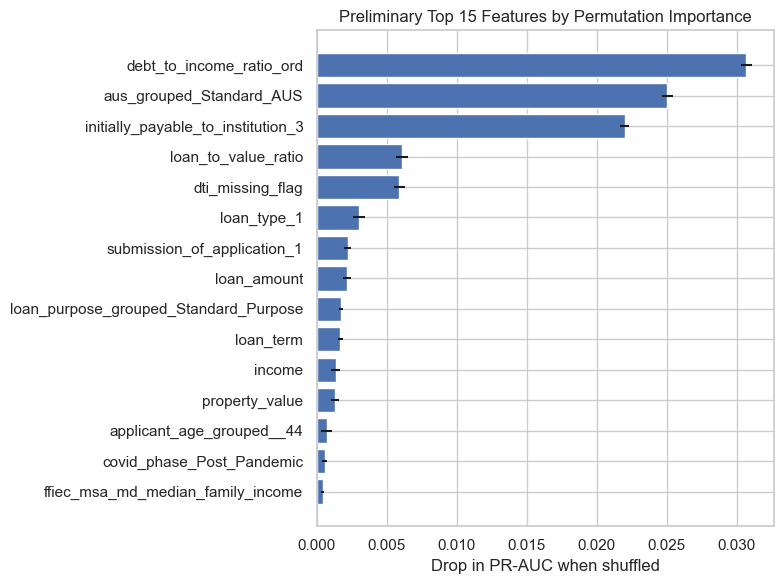

In [55]:
from sklearn.inspection import permutation_importance

result = permutation_importance(candidate_model, X_test, y_test, 
                                n_repeats=5, random_state=RANDOM_STATE, 
                                scoring='average_precision', n_jobs=-1)

importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': result.importances_mean,
    'importance_std':  result.importances_std,
}).sort_values('importance_mean', ascending=False).head(15)

print(importance_df)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['feature'][::-1], importance_df['importance_mean'][::-1],
         xerr=importance_df['importance_std'][::-1])
plt.xlabel('Drop in PR-AUC when shuffled')
plt.title('Preliminary Top 15 Features by Permutation Importance')
plt.tight_layout()
plt.savefig("permutation_importance_pre_leakage.png", dpi=120, bbox_inches="tight")
plt.show()

Dropping: ['initially_payable_to_institution_1', 'initially_payable_to_institution_1111', 'initially_payable_to_institution_2', 'initially_payable_to_institution_3']
Feature count now: 93

ROC-AUC:   0.8577
PR-AUC:    0.9455
Brier:     0.0952
F1 denial: 0.6357


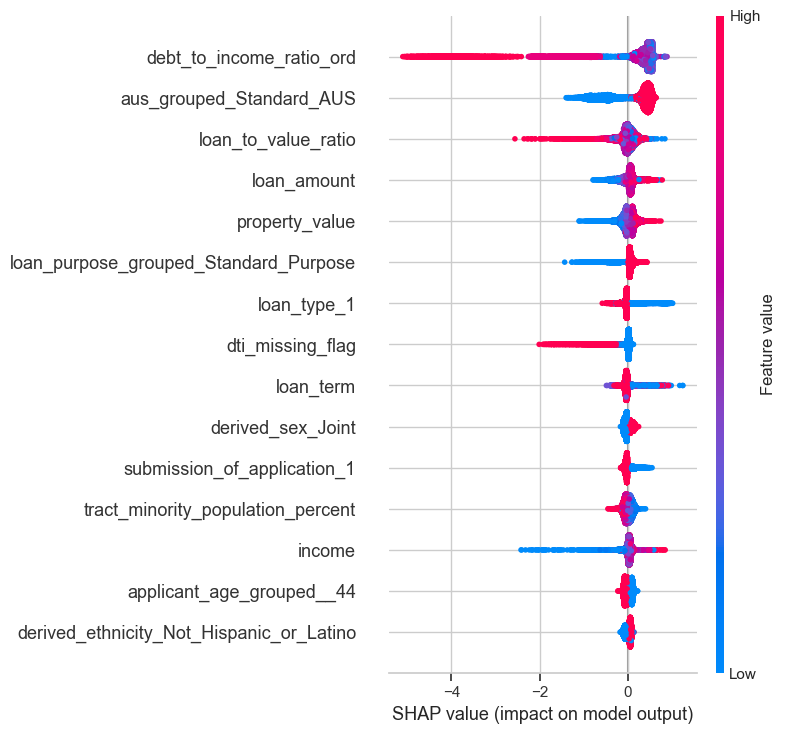

In [56]:

# Drop leakage features identified during model interpretation
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
leakage_cols = [c for c in X_train.columns if c.startswith("initially_payable_to_institution")]
print("Dropping:", leakage_cols)

X_train = X_train.drop(columns=leakage_cols)
X_test  = X_test.drop(columns=leakage_cols)

# Update feature_columns.json
feature_columns = X_train.columns.tolist()
with open("feature_columns.json", "w") as f:
    json.dump(feature_columns, f, indent=2)
print(f"Feature count now: {len(feature_columns)}")

# Refit calibrated LightGBM
lgbm_calibrated = CalibratedClassifierCV(
    estimator=lgb.LGBMClassifier(
        objective="binary",
        scale_pos_weight=neg_pos_ratio,
        num_leaves=63,
        n_estimators=500,
        learning_rate=0.03,
        min_child_samples=20,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ),
    method="isotonic",
    cv=5,
)
lgbm_calibrated.fit(X_train, y_train)
final_model = lgbm_calibrated

# Re-evaluate
y_proba = final_model.predict_proba(X_test)[:, 1]
y_pred  = final_model.predict(X_test)

print(f"\nROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_proba):.4f}")
print(f"Brier:     {brier_score_loss(y_test, y_proba):.4f}")
print(f"F1 denial: {f1_score(y_test, y_pred, pos_label=0):.4f}")

# Save updated artifacts
joblib.dump(final_model, "final_model.pkl")

# Refit raw LGBM for SHAP
final_lgbm_raw = lgb.LGBMClassifier(
    objective="binary", scale_pos_weight=neg_pos_ratio,
    num_leaves=63, n_estimators=500, learning_rate=0.03,
    min_child_samples=20, subsample=1.0, colsample_bytree=1.0,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)
final_lgbm_raw.fit(X_train, y_train)

# Regenerate SHAP
explainer = shap.TreeExplainer(final_lgbm_raw)
shap_values = explainer.shap_values(X_test)
np.save("shap_values_test.npy", shap_values)

shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.savefig("shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()


In [57]:


# Threshold analysis — final leakage-adjusted calibrated LightGBM

# The final model predicts approval probability: class 1 = approved, class 0 = denied.
# Applications with predicted approval probability below the threshold are flagged as likely denials.

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
threshold_rows = []

y_proba = final_model.predict_proba(X_test)[:, 1]

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)

    threshold_rows.append({
        "Threshold": t,
        "Precision (Denial)": precision_score(y_test, y_pred_t, pos_label=0, zero_division=0),
        "Recall (Denial)": recall_score(y_test, y_pred_t, pos_label=0, zero_division=0),
        "F1 (Denial)": f1_score(y_test, y_pred_t, pos_label=0, zero_division=0),
        "Flagged Rate": np.mean(y_pred_t == 0),
    })

threshold_results = pd.DataFrame(threshold_rows)

print("=== Threshold Sensitivity — Final Calibrated LightGBM ===")
display(threshold_results.round(3))

threshold_results.to_csv("threshold_sensitivity_final.csv", index=False)
print("Saved: threshold_sensitivity_final.csv")

best_row = threshold_results.loc[threshold_results["F1 (Denial)"].idxmax()]
best_threshold = best_row["Threshold"]

print(
    f"Best threshold by denial-class F1: {best_threshold:.2f} "
    f"| Precision={best_row['Precision (Denial)']:.3f} "
    f"| Recall={best_row['Recall (Denial)']:.3f} "
    f"| F1={best_row['F1 (Denial)']:.3f} "
    f"| Flagged Rate={best_row['Flagged Rate']:.3f}"
)




=== Threshold Sensitivity — Final Calibrated LightGBM ===


,Threshold,Precision (Denial),Recall (Denial),F1 (Denial),Flagged Rate
0,0.3,0.911,0.393,0.550,0.088
1,0.4,0.864,0.457,0.598,0.108
2,0.5,0.806,0.525,0.636,0.133
3,0.6,0.753,0.576,0.653,0.156
4,0.7,0.678,0.632,0.654,0.190


Saved: threshold_sensitivity_final.csv
Best threshold by denial-class F1: 0.70 | Precision=0.678 | Recall=0.632 | F1=0.654 | Flagged Rate=0.190



--- APPROVED case (index 6) ---
Predicted approval prob: 0.961
True label:              Approved


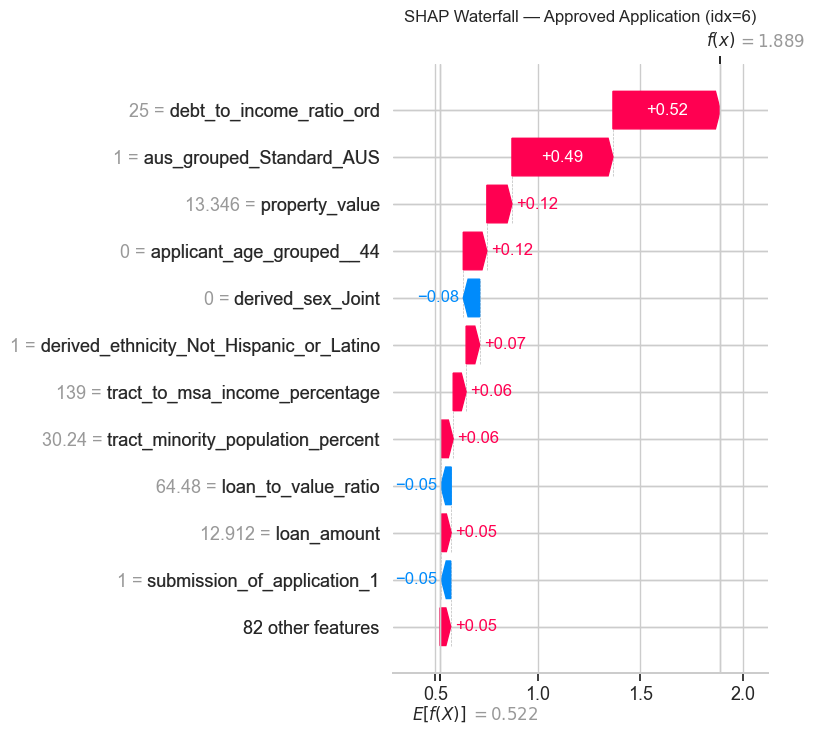


--- DENIED case (index 3) ---
Predicted approval prob: 0.076
True label:              Denied


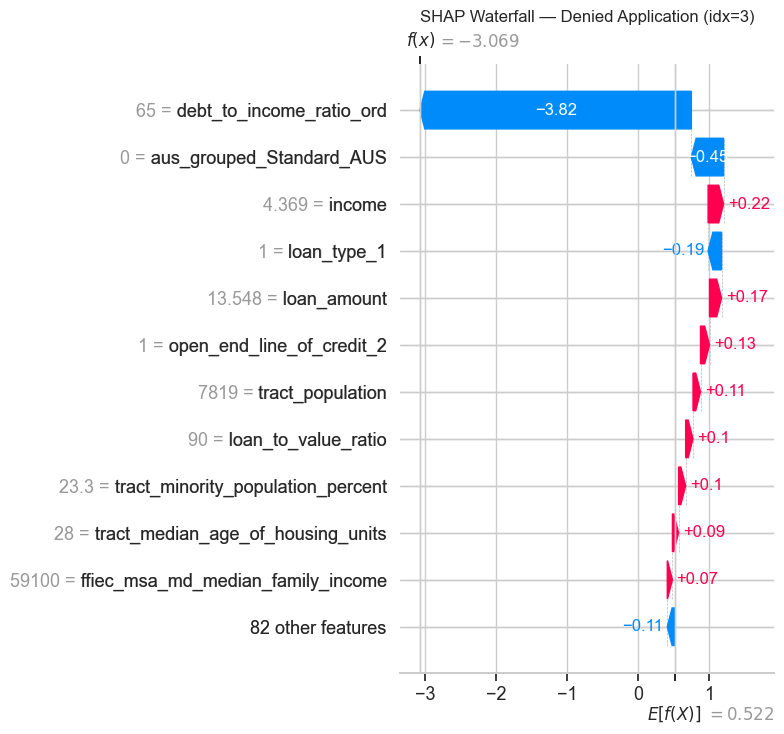


--- BORDERLINE case (index 4) ---
Predicted approval prob: 0.515
True label:              Approved


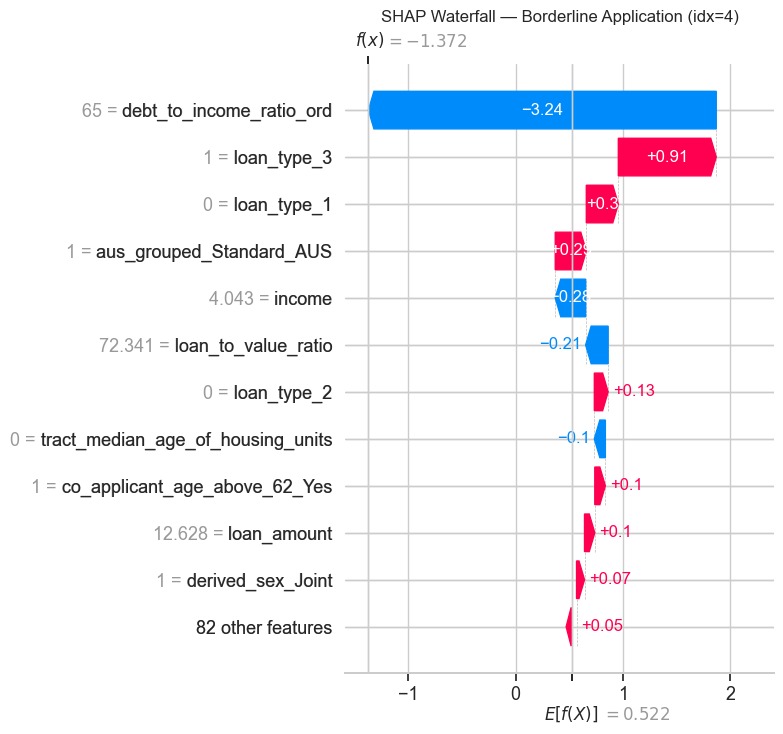

In [58]:

# SHAP force plots — local explanations for 3 example applicants

y_proba = final_model.predict_proba(X_test)[:, 1]

# Pick 3 representative cases
idx_approved   = np.where((y_proba > 0.95) & (y_test.values == 1))[0][0]   # high-confidence approve
idx_denied     = np.where((y_proba < 0.20) & (y_test.values == 0))[0][0]   # high-confidence deny
idx_borderline = np.where((y_proba > 0.45) & (y_proba < 0.55))[0][0]       # uncertain

cases = [
    ("approved",   idx_approved),
    ("denied",     idx_denied),
    ("borderline", idx_borderline),
]

for label, idx in cases:
    print(f"\n--- {label.upper()} case (index {idx}) ---")
    print(f"Predicted approval prob: {y_proba[idx]:.3f}")
    print(f"True label:              {'Approved' if y_test.iloc[idx]==1 else 'Denied'}")
    

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_test.iloc[idx].values,
            feature_names=X_test.columns.tolist(),
        ),
        max_display=12,
        show=False,
    )
    plt.title(f"SHAP Waterfall — {label.title()} Application (idx={idx})")
    plt.tight_layout()
    plt.savefig(f"shap_waterfall_{label}.png", dpi=120, bbox_inches="tight")
    plt.show()

Top 5 features for PDP: ['debt_to_income_ratio_ord', 'aus_grouped_Standard_AUS', 'loan_to_value_ratio', 'loan_amount', 'property_value']


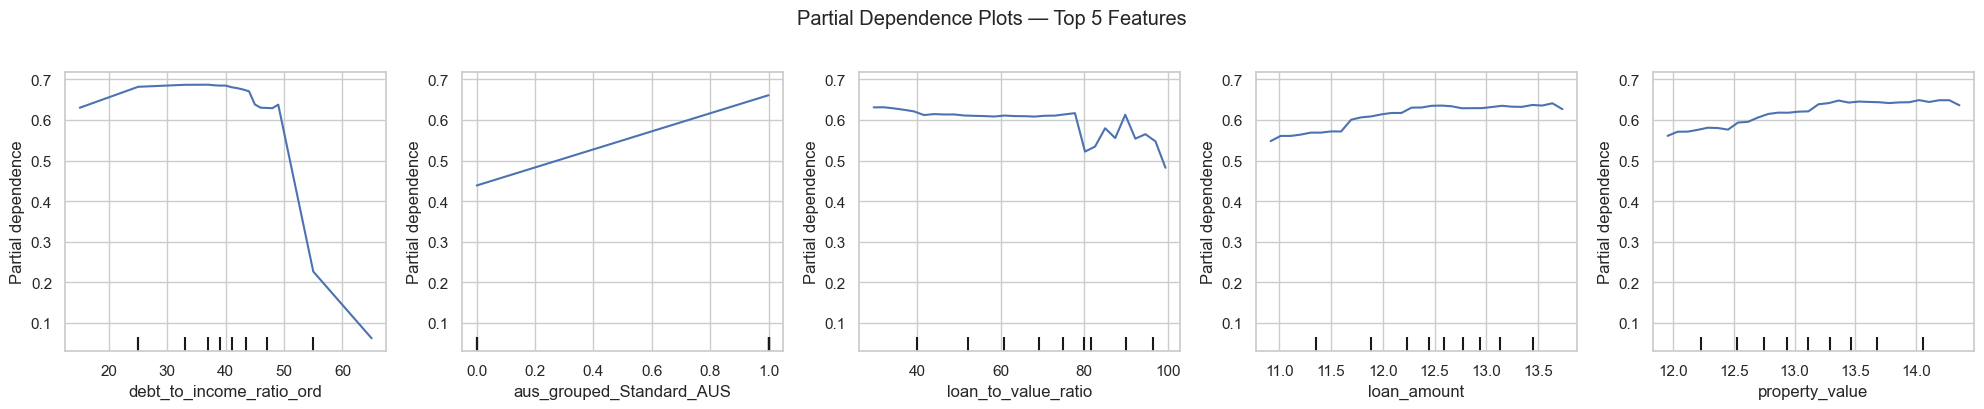

In [59]:

# Partial Dependence Plots — top 5 features

from sklearn.inspection import PartialDependenceDisplay

# Top 5 features by SHAP magnitude (use mean |SHAP| across test set)
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test.columns)
top5 = mean_abs_shap.sort_values(ascending=False).head(5).index.tolist()
print("Top 5 features for PDP:", top5)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
PartialDependenceDisplay.from_estimator(
    final_lgbm_raw,    
    X_test.sample(5000, random_state=42),  
    features=top5,
    ax=axes,
    grid_resolution=30,
    kind="average",
)
plt.suptitle("Partial Dependence Plots — Top 5 Features", y=1.02)
plt.tight_layout()
plt.savefig("pdp_top5.png", dpi=120, bbox_inches="tight")
plt.show()

In [60]:

# Fairness audit — subgroup approval rates + disparate impact

y_pred = final_model.predict(X_test)

# Reconstruct demographic columns from one-hot encoding
def reconstruct_group(df, prefix):
    """Given OHE columns starting with prefix, return the active category per row."""
    cols = [c for c in df.columns if c.startswith(prefix)]
    if not cols:
        return None
    # For each row, find which OHE column is 1
    return df[cols].idxmax(axis=1).str.replace(prefix, "", regex=False)

ethnicity = reconstruct_group(X_test, "derived_ethnicity_")
sex       = reconstruct_group(X_test, "derived_sex_")
state     = X_test["state_code_bin"].map({0: "CA", 1: "TX"})
age       = reconstruct_group(X_test, "applicant_age_grouped_")

audit_df = pd.DataFrame({
    "ethnicity": ethnicity,
    "sex": sex,
    "state": state,
    "age": age,
    "y_true": y_test.values,
    "y_pred": y_pred,
    "y_proba": y_proba,
})

def subgroup_metrics(df, group_col):
    """Compute per-subgroup approval rates and model performance."""
    rows = []
    for grp, sub in df.groupby(group_col):
        if len(sub) < 50:  # skip tiny groups
            continue
        rows.append({
            group_col: grp,
            "n":                  len(sub),
            "actual_approval":    sub["y_true"].mean(),
            "predicted_approval": sub["y_pred"].mean(),
            "model_auc":          roc_auc_score(sub["y_true"], sub["y_proba"]) if sub["y_true"].nunique() > 1 else np.nan,
        })
    return pd.DataFrame(rows).round(3)

print("=== By Ethnicity ===")
eth_table = subgroup_metrics(audit_df, "ethnicity")
print(eth_table)

print("\n=== By Sex ===")
print(subgroup_metrics(audit_df, "sex"))

print("\n=== By State ===")
print(subgroup_metrics(audit_df, "state"))

print("\n=== By Age ===")
print(subgroup_metrics(audit_df, "age"))

# Disparate impact ratio (80% rule)
# Compare each ethnicity group's predicted approval rate to the highest group
def disparate_impact(table, group_col):
    rates = table.set_index(group_col)["predicted_approval"]
    max_rate = rates.max()
    return (rates / max_rate).round(3)

print("\n=== Disparate Impact Ratio (Ethnicity) ===")
print("80% rule: ratios below 0.80 indicate potential disparate impact")
print(disparate_impact(eth_table, "ethnicity"))

# Save audit
audit_df.to_csv("fairness_audit_predictions.csv", index=False)
eth_table.to_csv("subgroup_rates.csv", index=False)

=== By Ethnicity ===
                 ethnicity      n  actual_approval  predicted_approval  \
0  Ethnicity_Not_Available   5312            0.790               0.879   
1       Hispanic_or_Latino   5562            0.726               0.793   
2                    Joint   1033            0.815               0.876   
3   Not_Hispanic_or_Latino  16072            0.822               0.889   

   model_auc  
0      0.841  
1      0.866  
2      0.866  
3      0.853  

=== By Sex ===
                 sex      n  actual_approval  predicted_approval  model_auc
0             Female   5590            0.774               0.829      0.877
1              Joint  10834            0.841               0.904      0.850
2               Male   8890            0.766               0.846      0.854
3  Sex_Not_Available   2685            0.762               0.873      0.821

=== By State ===
  state      n  actual_approval  predicted_approval  model_auc
0    CA  16848            0.814               0.890     

In [61]:

import joblib
import json

# 1. Final calibrated model
joblib.dump(final_model, "../app/final_model.pkl")
print("✓ final_model.pkl saved")

# 2. Raw LGBM (for fast SHAP in the app — TreeSHAP needs the underlying tree)
joblib.dump(final_lgbm_raw, "../app/final_lgbm_raw.pkl")
print("✓ final_lgbm_raw.pkl saved")

# 3. Feature columns (in correct order)
with open("../app/feature_columns.json", "w") as f:
    json.dump(X_train.columns.tolist(), f, indent=2)
print(f"✓ feature_columns.json saved ({len(X_train.columns)} features)")

# 4. Pre-computed SHAP values for the test set (so app doesn't compute on the fly for analysis tab)
np.save("../app/shap_values_test.npy", shap_values)
print(f"✓ shap_values_test.npy saved {shap_values.shape}")

# 5. Sanitization function (reused for new uploads)
sanitize_code = '''
import re
def sanitize_columns(df):
    """Replace special characters in column names for LightGBM compatibility."""
    df = df.copy()
    df.columns = [re.sub(r"[^A-Za-z0-9_]+", "_", col).strip("_") for col in df.columns]
    return df
'''
with open("../app/sanitize.py", "w") as f:
    f.write(sanitize_code)
print("✓ sanitize.py saved")

# 6. Test set + predictions for the "Explore Predictions" tab in the app
X_test_with_preds = X_test.copy()
X_test_with_preds["actual"] = y_test.values
X_test_with_preds["predicted_proba"] = y_proba
X_test_with_preds["predicted_class"] = y_pred
X_test_with_preds["ethnicity"] = ethnicity.values
X_test_with_preds["sex"] = sex.values
X_test_with_preds["state"] = state.values
X_test_with_preds.to_parquet("../app/test_predictions.parquet")
print(f"✓ test_predictions.parquet saved {X_test_with_preds.shape}")

# 7. Subgroup rates for the "applicants like you" feature in the app
audit_df.to_csv("../app/subgroup_audit.csv", index=False)
print("✓ subgroup_audit.csv saved")

# 8. Threshold table
print("✓ Done — all artifacts ready for app development")

✓ final_model.pkl saved
✓ final_lgbm_raw.pkl saved
✓ feature_columns.json saved (93 features)
✓ shap_values_test.npy saved (27999, 93)
✓ sanitize.py saved
✓ test_predictions.parquet saved (27999, 99)
✓ subgroup_audit.csv saved
✓ Done — all artifacts ready for app development
